<font size="5"><center>***Gestión de riesgos financieros (parte III).***</center></font>

<font size="4"><center>***Master en Ingeniería Matemática.***</center></font>

<font size="5"><center><span style="color:blue">***Nombre y Apellidos: Siria
Catherine Iñiguez Brito***</span></center></font>

In [14]:
nombreyapellidos = "Siria Catherine Iñiguez Brito"
if nombreyapellidos == "":
    print("Rellena tu nombre completo!")
else:
    print("Gracias!: ", nombreyapellidos, ":)")

Gracias!:  Siria Catherine Iñiguez Brito :)


---
## Importamos las librerías necesarias

In [15]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 4)

---
<font size="6"><center><span style="color:blue">***Prácticas GRF (parte III) — Sesión 1***</span></center></font>

Esta sesión cubre los conceptos fundamentales de **Value at Risk (VaR)** y **Expected Shortfall (ES)** a través de seis prácticas progresivas:

| Práctica | Contenido |
|----------|-----------|
| 1 | VaR paramétrico bajo normalidad (rentabilidades) |
| 2 | VaR paramétrico en términos nominales |
| 3 | VaR y ES empíricos con datos reales del SPY |
| 4 | VaR de una cartera de dos divisas |
| 5 | Efecto de la correlación sobre el VaR de cartera |
| 6 | VaR de una cartera con posiciones largas y cortas |

---
## Práctica 1 — VaR paramétrico bajo normalidad

**Enunciado:** Estamos interesados en calcular el $\text{VaR}_{1\%}$ de una rentabilidad que sigue una distribución $\mathcal{N}(\mu, \sigma^2)$ con momentos anualizados.

**Recordatorio teórico:**

Bajo el supuesto de normalidad, el VaR al nivel de significación $\alpha$ se define como:
$$\text{VaR}_\alpha = -(\mu + z_\alpha \cdot \sigma)$$
donde $z_\alpha = \Phi^{-1}(\alpha)$ es el cuantil $\alpha$ de la distribución normal estándar.

**Nota:** El signo negativo convierte la pérdida en un número positivo (convenio estándar en gestión de riesgos).

---
**Tarea:** Calcula el $\text{VaR}_{1\%}$ para un activo con $\mu = 8\%$ y $\sigma = 15\%$ anualizados. Utiliza `stats.norm.ppf()` para obtener el cuantil.

In [16]:
# Define los parámetros del activo
mu    =  0.08
sigma = 0.15
alpha = 0.01

# Calcula el cuantil z_alpha de la normal estándar
z_alpha = stats.norm.ppf(alpha)

# Calcula el VaR
umbral_x = mu + z_alpha * sigma
VaR_1 = - umbral_x

print("="*45)
print(f"{'RESULTADOS DE GESTIÓN DE RIESGOS':^45}")
print("="*45)
print(f"{'Rentabilidad Media (mu)':<30} | {mu*100:>10.2f}%")
print(f"{'Volatilidad (sigma)':<30} | {sigma*100:>10.2f}%")
print(f"{'Cuantil z (alpha=1%)':<30} | {z_alpha:>10.4f}")
print("-" * 45)
print(f"{'VaR (1%) Anualizado':<30} | {VaR_1*100:>10.4f}%")
print("="*45)

      RESULTADOS DE GESTIÓN DE RIESGOS       
Rentabilidad Media (mu)        |       8.00%
Volatilidad (sigma)            |      15.00%
Cuantil z (alpha=1%)           |    -2.3263
---------------------------------------------
VaR (1%) Anualizado            |    26.8952%


**Tarea:** Representa gráficamente la distribución normal del activo, destacando la cola izquierda al nivel $\alpha = 1\%$ y señalando la posición del VaR.

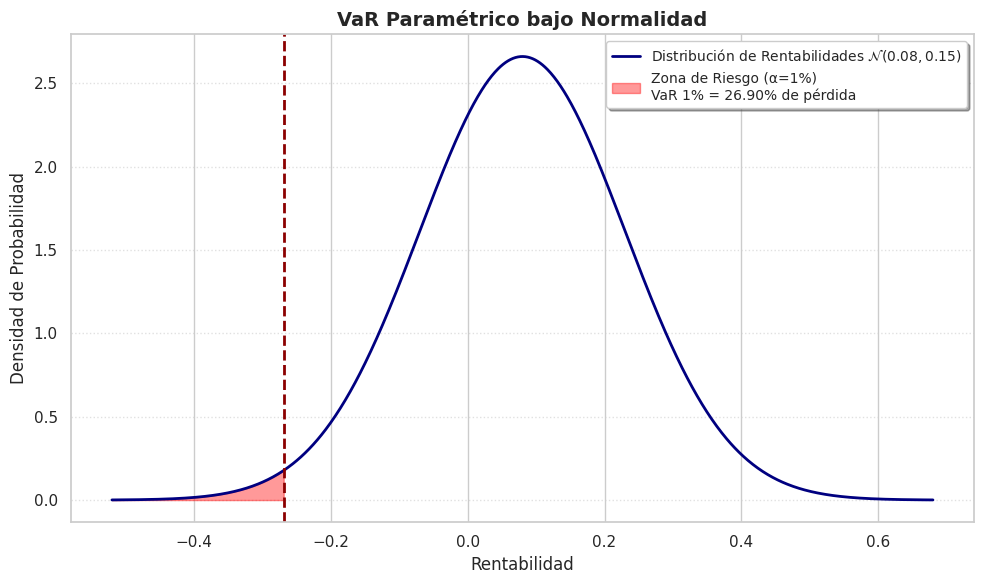

In [17]:
# Representación gráfica
# Sugerencia: usa np.linspace(), stats.norm.pdf() y ax.fill_between()

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar la campana
ax.plot(x, y, label=r'Distribución de Rentabilidades $\mathcal{N}(0.08, 0.15)$', color='navy', lw=2)

# Destacar la cola izquierda
x_fill = np.linspace(mu - 4*sigma, umbral_x, 100)
y_fill = stats.norm.pdf(x_fill, mu, sigma)
ax.fill_between(x_fill, y_fill, color='red', alpha=0.4,
                label=f'Zona de Riesgo (α={alpha*100:.0f}%)\nVaR 1% = {VaR_1*100:.2f}% de pérdida')

# Línea vertical en el umbral
ax.axvline(umbral_x, color='darkred', linestyle='--', lw=2)


ax.set_title(f'VaR Paramétrico bajo Normalidad', fontsize=14, fontweight='bold')
ax.set_xlabel('Rentabilidad', fontsize=12)
ax.set_ylabel('Densidad de Probabilidad', fontsize=12)

ax.grid(axis='y', linestyle=':', alpha=0.6)

# Leyenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)

plt.tight_layout()
plt.show()

**❓ Cuestión 1.1** ¿Qué significa exactamente que el $\text{VaR}_{1\%}$ sea $X\%$? Formula la interpretación en términos de probabilidad.

El **VaR al 1%** con un valor de **26.90%** significa que, bajo condiciones normales de mercado, existe una **probabilidad del 1%** de que la pérdida anual del activo sea igual o superior a dicho porcentaje. Expresado en términos de confianza, esto implica que tenemos un **99% de seguridad** de que las pérdidas anuales no excederán el 26.90% (o, lo que es lo mismo, que la rentabilidad no caerá por debajo del -26.90%).

Desde una perspectiva estadística, se esperaría que una pérdida de esta magnitud ocurra solamente **una vez cada 100 años**. Es importante entender este dato como un umbral: el VaR nos marca dónde empieza el 1% de los peores escenarios.

**❓ Cuestión 1.2** El VaR que acabas de calcular es anual. ¿Cómo lo convertirías a un horizonte de 10 días hábiles? ¿Qué supuesto estás asumiendo al hacer esa conversión? ¿Cuándo puede no ser válido ese supuesto?

Para convertir el VaR anual a un horizonte de **10 días hábiles**, se utiliza la regla de la raíz del tiempo: $\text{VaR}_{10d} = \text{VaR}_{anual} \cdot \sqrt{10/252}$ (asumiendo 252 días laborables al año). Al realizar esta conversión, se asume el **supuesto IID** (independencia e identidad), donde los retornos diarios no están correlacionados y mantienen una volatilidad constante. Este supuesto **puede no ser válido** en periodos de crisis o alta volatilidad, donde aparecen **clústeres de volatilidad** o colas pesadas, lo que provocaría que el VaR calculado subestime el riesgo real de corto plazo.

---
## Práctica 2 — VaR paramétrico en términos nominales

**Enunciado:** ¿Cuánto es el $\text{VaR}_{10\%}$ sobre horizonte de un año, de **2 millones de euros** invertidos en un fondo cuya rentabilidad anual en exceso del activo sin riesgo se distribuye $\mathcal{N}(5\%, 12\%^2)$?

---
**Tarea:** Calcula el VaR tanto en términos de rentabilidad como en términos nominales (euros).

In [18]:
# Define los parámetros
W       =  2_000_000
mu_2    = 0.05
sigma_2 = 0.12
alpha_2 = 0.10

# Cuantil
z_alpha2 =  stats.norm.ppf(alpha_2)

# VaR en rentabilidad y nominal
VaR_ret = -(mu_2 + z_alpha2 * sigma_2)
VaR_nom = VaR_ret * W


# Resultados
print(f"VaR_{{10%}} en rentabilidad : {VaR_ret*100:.2f}%")
print(f"VaR_{{10%}} nominal         : {VaR_nom:,.2f} €")

VaR_{10%} en rentabilidad : 10.38%
VaR_{10%} nominal         : 207,572.38 €


**❓ Cuestión 2.1** El enunciado indica que la rentabilidad es *en exceso* del activo sin riesgo. ¿Cambia algo en el cálculo si usamos la rentabilidad total en lugar del exceso? ¿En qué situaciones sería relevante esa distinción?


El uso de la rentabilidad total en lugar de la rentabilidad en exceso introduce un cambio directo en el parámetro de la **media ($\mu$)** de la distribución. Matemáticamente, la rentabilidad total se define como la suma de la rentabilidad en exceso más el rendimiento del activo sin riesgo ($R_{total} = R_{exc} + r_f$). Al integrar este componente, la distribución de rentabilidades se desplaza hacia la derecha en el eje horizontal, lo que resulta en un **VaR nominal inferior**. Esto sucede porque el rendimiento seguro del activo sin riesgo actúa como un margen de seguridad o "colchón" que compensa parte de la volatilidad, reduciendo así la pérdida potencial neta al final del periodo.

Esta distinción adquiere una relevancia crítica en función del contexto operativo y estratégico del análisis:

*   **Horizontes temporales de largo plazo:** Mientras que en mediciones diarias la tasa libre de riesgo suele ser despreciable, en horizontes anuales su efecto acumulado es significativo y omitirla llevaría a una sobreestimación del riesgo real de pérdida de capital.
*   **Entornos de tipos de interés elevados:** Cuando los tipos de interés son elevados, la diferencia entre ambos cálculos puede ser grande. Ignorar el rendimiento base que genera el dinero de forma segura nos daría una imagen distorsionada y demasiado pesimista del riesgo de nuestro capital.

**❓ Cuestión 2.2** Calcula también el $\text{VaR}_{1\%}$ y el $\text{VaR}_{5\%}$ para la misma inversión. ¿Qué relación observas entre el nivel de confianza y el valor del VaR? ¿Es esa relación lineal?




In [19]:
# Cálculo comparativo para distintos niveles de confianza

# Niveles de significancia a comparar
alphas = [0.10, 0.05, 0.01]

print(f"{'Alpha (%)':<10} | {'Cuantil z':<12} | {'VaR (%)':<12} | {'VaR Nominal (€)':<15}")
print("-" * 55)

for a in alphas:
    z = stats.norm.ppf(a)
    v_ret = -(mu_2 + z * sigma_2)
    v_nom = v_ret * W
    print(f"{a*100:>8.0f}% | {z:>12.4f} | {v_ret*100:>11.2f}% | {v_nom:>14,.2f}€")


Alpha (%)  | Cuantil z    | VaR (%)      | VaR Nominal (€)
-------------------------------------------------------
      10% |      -1.2816 |       10.38% |     207,572.38€
       5% |      -1.6449 |       14.74% |     294,764.87€
       1% |      -2.3263 |       22.92% |     458,323.49€


A partir de los cálculos realizados para los distintos niveles de significancia ($\alpha$), se obtienen los siguientes resultados comparativos:


1.  **Relación Inversa entre Alpha y VaR:** Se observa una relación donde, a medida que disminuye el nivel de significancia (es decir, aumenta el nivel de confianza del 90% al 99%), el valor del VaR aumenta. Esto es coherente con la gestión de riesgos: para garantizar una cobertura ante escenarios más extremos, debemos admitir una pérdida potencial mayor.

2.  **No Linealidad de la Relación:** La relación entre el nivel de confianza y el VaR **no es lineal**. Si observamos los incrementos:
    *   Al pasar del **10% al 5%** de significancia (una reducción de 5 puntos porcentuales), el VaR nominal aumenta en aproximadamente **87,192 €**.
    *   Sin embargo, al pasar del **5% al 1%** (una reducción de solo 4 puntos porcentuales), el VaR nominal se dispara en aproximadamente **163,558 €**.

Esta aceleración en el valor de la pérdida se debe a la naturaleza de la **distribución normal**. En las "colas" de la campana de Gauss, la densidad de probabilidad es mucho menor, lo que exige desplazamientos del cuantil $z$ cada vez más extensos para capturar porcentajes adicionales de confianza. En consecuencia, el riesgo crece de forma exponencial a medida que intentamos cubrir eventos de "cola" muy poco probables pero severos.

---
## Práctica 3 — VaR y ES empíricos con datos reales del SPY

**Enunciado:** Utilizando la serie de precios del S&P 500 (ticker SPY) del último año, calcula:

1. Un gráfico con el **drawdown**
2. La distribución de los **retornos logarítmicos**
3. El **Value at Risk** ($\text{VaR}_{5\%}$) histórico
4. El **Expected Shortfall** ($\text{ES}_{5\%}$) histórico

**Definiciones:**

- **Retorno logarítmico:** $R_t = \log\left(\dfrac{P_t}{P_{t-1}}\right)$

- **VaR histórico:** $\text{VaR}_\alpha = Q_\alpha(R_t)$, es decir, el cuantil $\alpha$ de la distribución empírica de retornos. Usa `.quantile()` sobre la serie de retornos.

- **Expected Shortfall:** $\text{ES}_\alpha = \mathbb{E}[R_t \mid R_t \leq \text{VaR}_\alpha]$, la media de los retornos que están por debajo del VaR.

- **Drawdown:** $DD_t = \dfrac{V_t - \max_{s \leq t} V_s}{\max_{s \leq t} V_s}$, caída acumulada desde el máximo histórico. Usa `.cummax()` sobre el valor acumulado.

---
**Tarea 3.1:** Carga el fichero `SPY.csv`, calcula los retornos logarítmicos y muestra estadísticas descriptivas básicas.

In [20]:
from google.colab import files
uploaded = files.upload()

Saving SPY.csv to SPY (2).csv


In [21]:
# Carga de datos
df = pd.read_csv("SPY.csv", parse_dates=["Date"], index_col="Date")
df = df.sort_index()

# Calcula los retornos logarítmicos
df["Return"] =np.log(df["Close"] / df["Close"].shift(1))
df = df.dropna()

# Muestra estadísticas básicas
print("Estadísticas Descriptivas de los Retornos:")
print(df["Return"].describe())
print(f"\nSesgo: {df['Return'].skew():.4f}")
print(f"Kurtosis : {df['Return'].kurt():.4f}")
print("-" * 30)


Estadísticas Descriptivas de los Retornos:
count    250.000000
mean       0.000433
std        0.012744
min       -0.060327
25%       -0.003575
50%        0.001200
75%        0.006192
max        0.099863
Name: Return, dtype: float64

Sesgo: 0.9242
Kurtosis : 17.3536
------------------------------


**Tarea 3.2:** Calcula y representa el drawdown del SPY en el periodo.

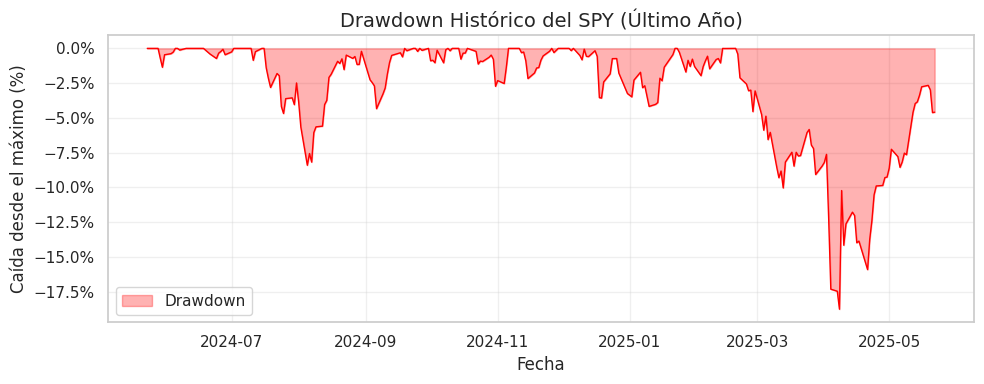

In [22]:
# Calcula el drawdown
# Sugerencia: calcula primero la rentabilidad acumulada con (1 + R).cumprod()
# luego el máximo acumulado con .cummax()


# 1. Convertimos retornos logarítmicos a simples para usar la sugerencia:
# R_simple = exp(R_log) - 1
# Por tanto: (1 + R_simple) es simplemente np.exp(df["Return"])

# Calculamos la rentabilidad acumulada:
wealth_index = (np.exp(df["Return"])).cumprod()

# 2. Calculamos el máximo acumulado
previous_peaks = wealth_index.cummax()

# 3. Calculamos el drawdown
drawdown = (wealth_index - previous_peaks) / previous_peaks

# --- Representación Gráfica ---
plt.figure(figsize=(10, 4))

# Rellenamos el área para visualizar la "caída"
plt.fill_between(drawdown.index, drawdown, color='red', alpha=0.3, label='Drawdown')

# Dibujamos la línea del drawdown
plt.plot(drawdown.index, drawdown, color='red', lw=1)


plt.title("Drawdown Histórico del SPY (Último Año)", fontsize=14)
plt.ylabel("Caída desde el máximo (%)")
plt.xlabel("Fecha")

import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Tarea 3.3:** Calcula el $\text{VaR}_{5\%}$ y el $\text{ES}_{5\%}$ históricos.



In [23]:
alpha_3 = 0.05

# VaR histórico
VaR_3 = df["Return"].quantile(alpha_3)

# ES histórico: media de los retornos por debajo del VaR
ES_3 = df[df["Return"] <= VaR_3]["Return"].mean()


print(f"VaR_{{5%}} histórico : {VaR_3:.4%}")
print(f"ES_{{5%}}  histórico : {ES_3:.4%}")

VaR_{5%} histórico : -1.8396%
ES_{5%}  histórico : -3.0131%


**Tarea 3.4:** Representa la distribución de retornos superponiendo la curva normal teórica y señalando el VaR y el ES.

**Nota:** Usa `sns.histplot()` con el parámetro `kde=True`. La función `sns.distplot()` está **deprecada** desde seaborn 0.11 y ha sido **eliminada** en versiones posteriores.

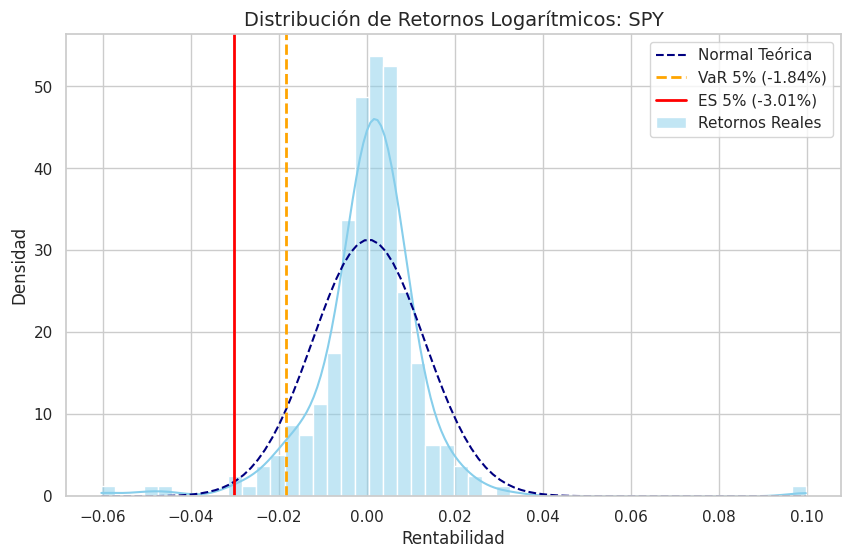

In [24]:
# Distribución de retornos con VaR y ES
# Sugerencia: usa sns.histplot(..., kde=True) y ax.axvline() para las líneas

plt.figure(figsize=(10, 6))

# Histograma
sns.histplot(df["Return"], kde=True, bins=50, color='skyblue', stat="density", label="Retornos Reales")

# Superponer curva normal teórica para comparar
mu, std = df["Return"].mean(), df["Return"].std()
x = np.linspace(df["Return"].min(), df["Return"].max(), 100)
plt.plot(x, norm.pdf(x, mu, std), color='navy', linestyle='--', label="Normal Teórica")

# Líneas verticales para VaR y ES
plt.axvline(VaR_3, color='orange', linestyle='--', lw=2, label=f'VaR 5% ({VaR_3:.2%})')
plt.axvline(ES_3, color='red', linestyle='-', lw=2, label=f'ES 5% ({ES_3:.2%})')

plt.title("Distribución de Retornos Logarítmicos: SPY", fontsize=14)
plt.xlabel("Rentabilidad")
plt.ylabel("Densidad")
plt.legend()
plt.show()

**❓ Cuestión 3.1** Compara visualmente el histograma de retornos con la curva normal teórica. ¿Qué observas en las colas? ¿Qué implicaciones tiene esto para el uso del VaR paramétrico bajo normalidad en la práctica?

Al contrastar el histograma con la curva normal, se evidencia que los retornos del SPY no siguen una distribución gaussiana, presentando dos anomalías críticas:

1.  **Curtosis Excesiva:** El gráfico muestra un "pico" central mucho más pronunciado que la normal, lo que indica que la mayoría de los rendimientos se agrupan muy cerca de la media, pero con una frecuencia muy superior a la teórica.
2.  **Presencia de Colas Pesadas (Fat Tails):** Es especialmente notable en el extremo izquierdo (pérdidas), donde aparecen barras aisladas en niveles de **-0.04 y -0.06**. La curva normal teórica en esos puntos ya tiene una densidad de casi cero, lo que significa que el modelo normal consideraría esos eventos como "imposibles" o extremadamente improbables, cuando en la realidad han ocurrido.

**Implicaciones para el VaR Paramétrico:**
Utilizar un VaR paramétrico bajo normalidad en este escenario sería peligroso, ya que ignoraría por completo esos eventos extremos situados en el extremo izquierdo. Mientras que la normal situaría el riesgo en una zona mucho más cercana al centro, el **VaR histórico (-1.84%)** y, sobre todo, el **Expected Shortfall (-3.01%)** capturan la realidad de que, cuando el mercado cae, las pérdidas pueden ser mucho más profundas de lo que sugiere la campana de Gauss. En conclusión, la normalidad subestima sistemáticamente el "riesgo de catástrofe".

**❓ Cuestión 3.2** El ES es siempre mayor (en valor absoluto) que el VaR al mismo nivel de confianza. ¿Por qué? ¿En qué tipo de distribuciones esperas que la diferencia entre ambos sea mayor: en distribuciones con colas finas o con colas gruesas?

El **Expected Shortfall (ES)** es, por definición, siempre mayor en valor absoluto que el **VaR** al mismo nivel de confianza. Matemáticamente, mientras que el VaR es simplemente un cuantil o punto de corte ($\text{VaR}_\alpha = Q_\alpha$), el ES se define como la esperanza condicionada de las pérdidas que superan dicho umbral:

$$\text{ES}_\alpha = \mathbb{E}[R \mid R \leq \text{VaR}_\alpha]$$

Al ser una media aritmética de todos los valores situados en el extremo izquierdo de la distribución, el ES siempre será un valor más extremo (o igual en distribuciones degeneradas) que el propio límite donde comienza esa zona.

Respecto a la diferencia entre ambos, el comportamiento varía según la forma de la distribución:

* **Distribuciones de colas finas (como la Normal):** La diferencia es moderada. Debido a que la función de densidad decae exponencialmente hacia cero, los valores que exceden el VaR están muy acotados y la media de la cola no se aleja demasiado del punto de corte.
* **Distribuciones de colas gruesas (Fat Tails):** La brecha entre el ES y el VaR será **mucho mayor**. En estas distribuciones, la probabilidad de observar eventos extremos (*outliers*) es significativa. Estos valores extremadamente negativos actúan como un "lastre" que desplaza la esperanza matemática ($\text{ES}$) hacia la izquierda, alejándola considerablemente del cuantil ($\text{VaR}$).

En conclusión, la magnitud de la diferencia entre el VaR y el ES es un indicador directo de la **curtosis** y la peligrosidad de la cola; cuanto mayor es la distancia, más "pesada" es la cola y más necesaria resulta la gestión del riesgo mediante ES para capturar posibles eventos catastróficos.

**❓ Cuestión 3.3** Basilea III migró del $\text{VaR}_{1\%}$ al $\text{ES}_{2.5\%}$ como medida regulatoria. Teniendo en cuenta lo que has calculado, ¿qué ventajas ofrece el ES frente al VaR para un regulador que quiere proteger la estabilidad del sistema financiero?

La migración del **VaR al Expected Shortfall (ES)** bajo el marco de Basilea III responde a dos deficiencias críticas del VaR que el ES logra solventar para un regulador:

1.  **Captura del "Riesgo de Cola" (Tail Risk):** El VaR es "ciego" a la magnitud de las pérdidas una vez que se supera el umbral crítico. Para un regulador, no es lo mismo que un banco tenga una probabilidad del 1% de perder 100 millones, a que tenga esa misma probabilidad de perder 5.000 millones. El ES obliga a las instituciones a mantener capital suficiente para cubrir la **severidad media** de las crisis, no solo su frecuencia.
2.  **Propiedad de Coherencia (Subaditividad):** Desde un punto de vista matemático, el VaR no siempre cumple con la propiedad de subaditividad, lo que significa que, en ciertos escenarios, el VaR de una cartera diversificada podría ser mayor que la suma de los VaR de sus partes. Esto desincentiva la diversificación. El **ES es una medida de riesgo coherente**, lo que garantiza que la diversificación siempre sea reconocida como una reducción del riesgo sistémico.
3.  **Estabilidad ante eventos extremos:** Como se observa en los datos del SPY, los mercados reales presentan "colas pesadas". Al pasar de un nivel de confianza del 99% (VaR 1%) a un promedio de la cola del 2.5% (ES 2.5%), el regulador busca una métrica que sea **más estable y menos sensible** a un solo dato atípico, pero que al mismo tiempo sea mucho más conservadora respecto a las pérdidas potenciales catastróficas.

En resumen, el ES ofrece una visión más realista y prudente de la solvencia necesaria para evitar rescates financieros en escenarios de pánico de mercado.

---
## Práctica 4 — VaR de una cartera de dos divisas

**Enunciado:** Cartera invertida en dos divisas frente al euro, supuestas **incorrelacionadas** ($\rho = 0$):

| Activo | Inversión | Volatilidad anual |
|--------|-----------|-------------------|
| Dólar  | 2.000.000 € | 5% |
| Yen    | 1.000.000 € | 12% |

**Recordatorio:** Para una cartera de dos activos:
$$\sigma_c^2 = W_1^2 \sigma_1^2 + W_2^2 \sigma_2^2 + 2\rho W_1 W_2 \sigma_1 \sigma_2$$
$$\text{VaR}_\alpha^{\text{div}} = z_\alpha \cdot \sigma_c \qquad \text{VaR}_\alpha^{\text{no div}} = \text{VaR}_1 + \text{VaR}_2$$

---
**Tarea:** Calcula la varianza y volatilidad de la cartera, el $\text{VaR}_{95\%}$ a 1 año y a 1 día, tanto diversificado como no diversificado.

In [25]:
# Parámetros
W1, W2 = 2_000_000, 1_000_000
s1, s2 = 0.05, 0.12
rho    = 0
z_95   = stats.norm.ppf(0.95)

# Varianza y volatilidad de la cartera
var_cartera = (W1**2 * s1**2) + (W2**2 * s2**2) + (2 * rho * W1 * W2 * s1 * s2)
vol_cartera = np.sqrt(var_cartera)

# VaR individuales, diversificado y no diversificado
VaR_1_anual     = W1 * s1 * z_95
VaR_2_anual     = W2 * s2 * z_95

VaR_anual_div   = vol_cartera * z_95
VaR_anual_nodiv = VaR_1_anual + VaR_2_anual


# VaR a 1 día (regla de la raíz del tiempo, 252 días hábiles)
VaR_diario_div  = VaR_anual_div / np.sqrt(252)
VaR_diario_nodiv = VaR_anual_nodiv / np.sqrt(252)

# --- Resultados ---
print(f"Varianza cartera       : {var_cartera:,.2f}")
print(f"Volatilidad cartera (€): {vol_cartera:,.2f} €")
print("-" * 40)
print(f"VaR individual dólar   : {VaR_1_anual:,.2f} €")
print(f"VaR individual yen     : {VaR_2_anual:,.2f} €")
print(f"VaR no diversificado   : {VaR_anual_nodiv:,.2f} €")
print(f"VaR diversificado anual: {VaR_anual_div:,.2f} €")
print(f"VaR diversificado 1 día : {VaR_diario_div:,.2f} €")
print(f"VaR no diversificado 1 día : {VaR_diario_nodiv:.2f} €")


Varianza cartera       : 24,400,000,000.00
Volatilidad cartera (€): 156,204.99 €
----------------------------------------
VaR individual dólar   : 164,485.36 €
VaR individual yen     : 197,382.44 €
VaR no diversificado   : 361,867.80 €
VaR diversificado anual: 256,934.35 €
VaR diversificado 1 día : 16,185.34 €
VaR no diversificado 1 día : 22795.53 €


**❓ Cuestión 4.1** ¿Cuánto es el beneficio de la diversificación en euros? Exprésalo también como porcentaje de reducción respecto al VaR no diversificado.

A partir de los cálculos realizados para la cartera de divisas, el beneficio de la diversificación se analiza de la siguiente manera:

1.  **Beneficio en términos absolutos:** El ahorro por diversificación asciende a **104.933,45 €**. Este valor representa la diferencia entre el riesgo asumido si las divisas estuvieran perfectamente correlacionadas (VaR no diversificado: 361.867,80 €) y el riesgo real de la cartera al estar incorrelacionadas (VaR diversificado: 256.934,35 €).

2.  **Porcentaje de reducción:** Para calcular la eficiencia de la diversificación, comparamos este ahorro respecto al riesgo inicial sin diversificar:

$$\% \text{ Reducción} = \frac{\text{Ahorro}}{\text{VaR no diversificado}} \times 100$$.


$$\% \text{ Reducción} = \frac{104.933,45}{361.867,80} \times 100 \approx \mathbf{29,00\%}$$

**Conclusión:** La diversificación ha permitido reducir el riesgo potencial de la inversión en un **29%**. Este beneficio ocurre porque, al tener una correlación nula ($\rho=0$), la probabilidad de que ambas divisas sufran su peor escenario de pérdida de forma simultánea es estadísticamente muy baja, lo que permite compensar volatilidades y optimizar el consumo de capital.

In [26]:
# Beneficio de la diversificación
ahorro = VaR_anual_nodiv - VaR_anual_div
print("-" * 40)
print(f"Ahorro por diversificación: {ahorro:,.2f} €")

----------------------------------------
Ahorro por diversificación: 104,933.45 €


**❓ Cuestión 4.2** La regla de la raíz del tiempo asume que los retornos diarios son independientes e idénticamente distribuidos. ¿En qué situaciones prácticas puede fallar este supuesto? ¿Qué consecuencias tendría sobre el VaR estimado?

La regla de la raíz del tiempo se basa en el supuesto de que los retornos siguen un "camino aleatorio" (*random walk*), siendo independientes e idénticamente distribuidos (i.i.d.). Sin embargo, en la práctica financiera, este supuesto puede fallar en las siguientes situaciones:

1.  **Autocorrelación y Persistencia (Momentum):** En muchos activos, los retornos no son independientes; una caída hoy suele aumentar la probabilidad de otra caída mañana. Si existe autocorrelación positiva, la volatilidad real crece más rápido que $\sqrt{T}$.
2.  **Agrupamiento de Volatilidad (Volatility Clustering):** Los mercados presentan periodos de calma seguidos de periodos de alta agitación. Durante una crisis, la varianza no es constante, lo que invalida el supuesto de "idénticamente distribuidos".
3.  **Fenómenos de Reversión a la Media:** En horizontes muy largos, algunos activos tienden a volver a su valor promedio, lo que haría que el riesgo creciera más despacio de lo que predice la raíz del tiempo.

#### Consecuencias sobre el VaR estimado:

* **Subestimación del riesgo:** Si los retornos presentan persistencia o estamos en un periodo de alta volatilidad, la regla de la raíz del tiempo **infravalorará el VaR**. Esto significa que la pérdida real en un horizonte de 10 días o un año podría ser significativamente mayor a la proyectada, dejando a la institución con capital insuficiente.
* **Falsa sensación de seguridad:** Al asumir una distribución constante, el gestor ignora el "efecto bola de nieve" de las crisis financieras, donde la liquidez desaparece y las correlaciones aumentan, haciendo que el VaR calculado sea demasiado optimista.

---
## Práctica 5 — Efecto de la correlación sobre el VaR de cartera

**Enunciado:** Usando los mismos activos de la Práctica 4, analiza el $\text{VaR}_c$ de la cartera bajo dos casos extremos:
1. Activos **incorrelacionados** ($\rho = 0$)
2. Activos **perfectamente correlacionados** ($\rho = 1$)

Extiende el análisis representando el VaR de cartera como función de $\rho \in [-1, 1]$.

---
**Tarea:** Define una función `var_cartera_2activos()` que reciba los parámetros y devuelva el VaR, y úsala para analizar ambos casos.

In [27]:
def var_cartera_2activos(W1, W2, s1, s2, rho, alpha=0.95):
    """VaR paramétrico de una cartera de dos activos."""
    # Completa la función
    pass

# Calcula VaR para rho=0 y rho=1
VaR_rho0 =
VaR_rho1 =

print(f"VaR cartera (ρ = 0) : ")
print(f"VaR cartera (ρ = 1) : ")
print(f"Suma VaRs individuales: ")

SyntaxError: invalid syntax (996582889.py, line 7)

**Tarea:** Representa el VaR de cartera en función de $\rho \in [-1, 1]$ y señala los casos $\rho = 0$ y $\rho = 1$.

In [ ]:
# Gráfico: VaR de cartera en función de rho
rho_range = np.linspace(-1, 1, 200)

# Calcula el VaR para cada valor de rho
VaR_range =

# Representa


**❓ Cuestión 5.1** Verifica algebraicamente que cuando $\rho = 1$, el VaR de la cartera es exactamente igual a la suma de los VaRs individuales. Muéstralo desarrollando la expresión de $\sigma_c$.

*Escribe tu demostración aquí:*

**❓ Cuestión 5.2** Observa el gráfico para $\rho < 0$. ¿Qué ocurre con el VaR de cartera cuando los activos están negativamente correlacionados? ¿Tiene sentido económico? ¿Se puede tener $\rho = -1$ en la práctica entre dos divisas?

*Escribe tu respuesta aquí:*

**❓ Cuestión 5.3** El hecho de que $\text{VaR}_c \leq \text{VaR}_1 + \text{VaR}_2$ cuando $\rho \leq 1$ se conoce como **subaditibidad** del VaR bajo normalidad. Sin embargo, el VaR *no* es subaditivo en general (para distribuciones no normales). ¿Qué implicaciones tiene esto para la gestión del riesgo de carteras en periodos de crisis, cuando las correlaciones tienden a 1?

*Escribe tu respuesta aquí:*

---
## Práctica 6 — VaR de una cartera con posiciones largas y cortas

**Enunciado:** Cartera con posiciones en tres divisas frente al euro:

| Divisa | Posición (\$) | Volatilidad anual |
|--------|--------------|-------------------|
| Dólar canadiense | −767 (corta) | 5.54% |
| Dólar USA | +117 (larga) | 12.82% |
| Yen japonés | +108 (larga) | 16.63% |

Con la siguiente matriz de correlaciones:
$$M = \begin{pmatrix} 1 & -0.21 & -0.21 \\ -0.21 & 1 & 0.79 \\ -0.21 & 0.79 & 1 \end{pmatrix}$$

**Recordatorio:** Para una cartera de $n$ activos con vector de posiciones $\mathbf{x}$ y matriz de covarianzas $\Sigma$:
$$\sigma_c^2 = \mathbf{x}^\top \Sigma \, \mathbf{x} \qquad \text{VaR}_c = z_\alpha \cdot \sigma_c$$
La matriz de covarianzas se construye como $\Sigma = D \cdot C \cdot D$ donde $D = \text{diag}(\boldsymbol{\sigma})$ y $C$ es la matriz de correlaciones.

---
**Tarea:** Calcula los $\text{VaR}_{95\%}$ mensuales individuales y el VaR diversificado de la cartera.


In [ ]:
# Posiciones nominales y volatilidades
positions = np.array([])
vols      = np.array([])

# Matriz de correlaciones
corr = np.array([
    [],
    [],
    []
])

# Construye la matriz de covarianzas Σ = D · C · D
D   =
cov =

# VaR individuales mensuales
# Recuerda: σ_mensual = |posición| × σ_anual / √12
vol_ind_mensual =
VaR_ind         =

print("VaR 95% mensuales individuales:")
for i, nombre in enumerate(["CAD", "USD", "JPY"]):
    print(f"  {nombre}: ")

# VaR de la cartera
# Recuerda: usa la covarianza mensual (Σ / 12)
cov_mensual =
var_port    =
vol_port    =
VaR_port    =

print(f"\nVaR 95% cartera diversificado    : ")
print(f"VaR 95% cartera no diversificado : ")

**❓ Cuestión 6.1** La cartera tiene una posición **corta** en dólar canadiense. ¿Cómo afecta una posición corta al cálculo del VaR individual? ¿Y al VaR de cartera cuando esa posición está negativamente correlacionada con las demás?

*Escribe tu respuesta aquí:*

**❓ Cuestión 6.2** El VaR de la cartera (≈27.6\$) es inferior a la suma de los VaRs individuales (≈35.9\$). Identifica qué elementos de la estructura de correlaciones contribuyen más a esa reducción de riesgo.

*Escribe tu respuesta aquí:*

**❓ Cuestión 6.3 (avanzada)** Durante una crisis financiera, las correlaciones entre activos tienden a aumentar y aproximarse a 1. Recalcula el VaR de la cartera asumiendo que todas las correlaciones pasan a ser $\rho = 0.9$. ¿Cuánto aumenta el riesgo de la cartera respecto al escenario original?

*Escribe tu respuesta aquí (incluye el código):*

In [ ]:
# Escenario de crisis: correlaciones elevadas
